In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [58]:
import os

print("spam_model.pkl:", os.path.getsize("spam_model.pkl") / 1024, "KB")
print("tfidf_vectorizer.pkl:", os.path.getsize("tfidf_vectorizer.pkl") / 1024, "KB")

spam_model.pkl: 178.9130859375 KB
tfidf_vectorizer.pkl: 122.33203125 KB


In [57]:
import joblib

joblib.dump(nb_model_improved, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


In [3]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

urllib.request.urlretrieve(url, "sms_spam_collection.zip")

with zipfile.ZipFile("sms_spam_collection.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset downloaded and extracted successfully!")

Dataset downloaded and extracted successfully!


In [4]:
import os

print(os.listdir("data"))

['readme', 'SMSSpamCollection']


In [5]:
df = pd.read_csv(
    "data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (5572, 2)

Column Names:
['label', 'message']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
print("\nLabel Distribution:")
print(df["label"].value_counts())


Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
label      0
message    0
dtype: int64


In [9]:
print("Number of duplicate messages:", df.duplicated().sum())

Number of duplicate messages: 403


In [10]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [11]:
label_counts = df["label"].value_counts()

print(label_counts)

label
ham     4516
spam     653
Name: count, dtype: int64


In [12]:
print("Number of duplicate messages:", df.duplicated().sum())

Number of duplicate messages: 0


In [13]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


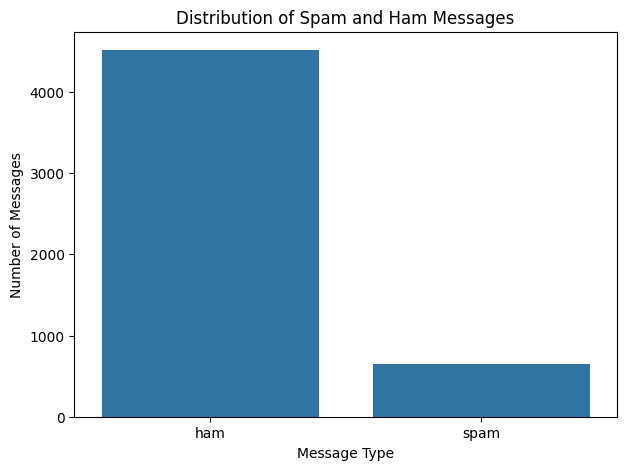

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [15]:
label_percentage = df["label"].value_counts(normalize=True) * 100

print(label_percentage.round(2))

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


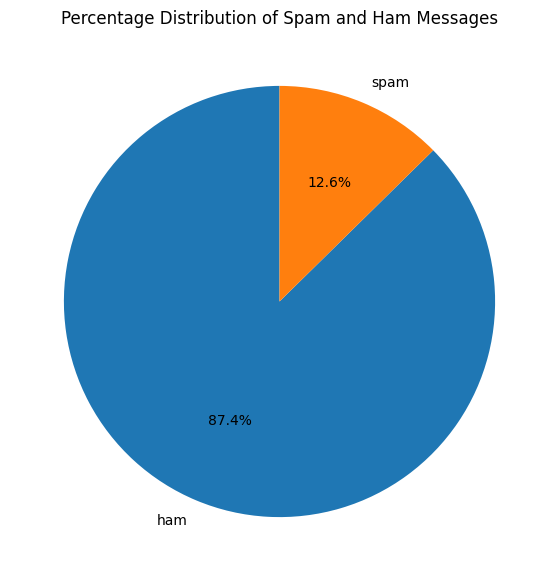

In [16]:
plt.figure(figsize=(7, 7))

plt.pie(
    label_percentage,
    labels=label_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Spam and Ham Messages")

plt.show()

In [17]:
df["message_length"] = df["message"].apply(len)

df[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
print(df.groupby("label")["message_length"].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.905890  56.715046   2.0   34.0   53.0   91.0  910.0
spam    653.0  137.704441  29.821348  13.0  132.0  148.0  157.0  223.0


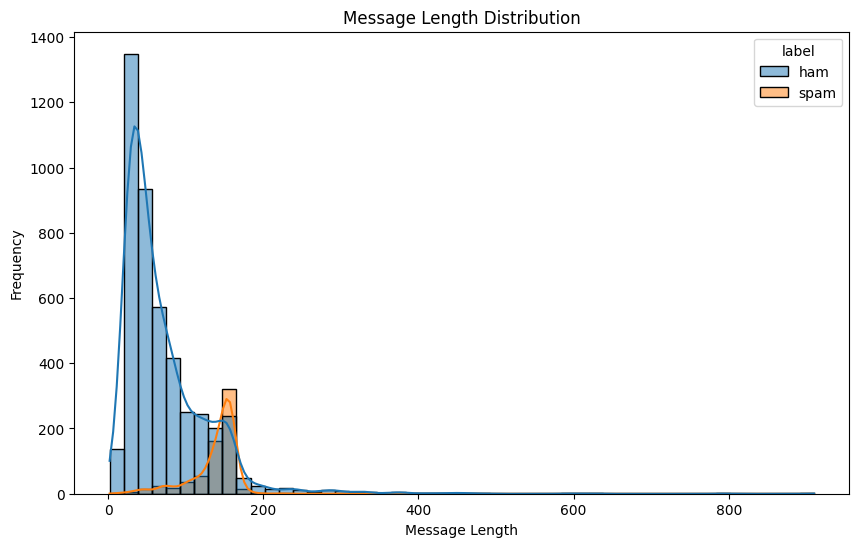

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

In [20]:
average_length = df.groupby("label")["message_length"].mean()

print("Average message length:")
print(average_length)

Average message length:
label
ham      70.905890
spam    137.704441
Name: message_length, dtype: float64


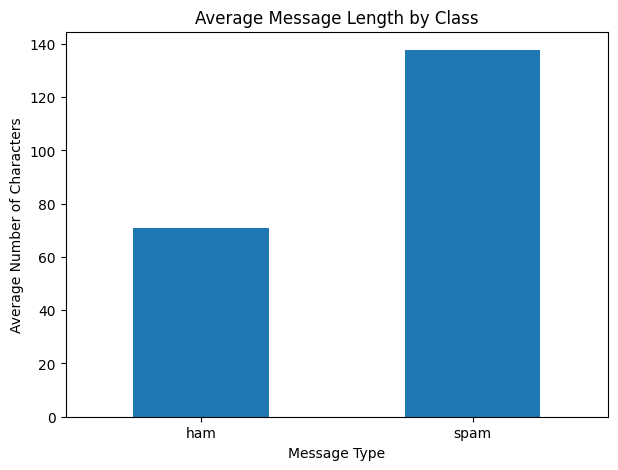

In [21]:
plt.figure(figsize=(7, 5))

average_length.plot(kind="bar")

plt.title("Average Message Length by Class")
plt.xlabel("Message Type")
plt.ylabel("Average Number of Characters")

plt.xticks(rotation=0)

plt.show()

In [22]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [23]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


In [24]:
def preprocess_text(text):

    text = text.lower()


    text = re.sub(r"http\S+|www\S+|https\S+", "", text)


    text = re.sub(r"[^a-zA-Z\s]", "", text)


    tokens = word_tokenize(text)


    tokens = [word for word in tokens if word not in stop_words]


    return " ".join(tokens)

In [25]:
sample_message = df["message"].iloc[0]

print("Original message:")
print(sample_message)

print("\nPreprocessed message:")
print(preprocess_text(sample_message))

Original message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Preprocessed message:
go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [26]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["label", "message", "clean_message"]].head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [27]:
for i in range(5):
    print("Original :", df.loc[i, "message"])
    print("Cleaned  :", df.loc[i, "clean_message"])
    print("-" * 80)

Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned  : go jurong point crazy available bugis n great world la e buffet cine got amore wat
--------------------------------------------------------------------------------
Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joking wif u oni
--------------------------------------------------------------------------------
Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs
--------------------------------------------------------------------------------
Original : U dun say so early hor... U c already then say...
Cleaned  : u dun say early hor u c already say
----------------------------------------------------------------------

In [28]:
X = df["clean_message"]
y = df["label"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [30]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 7363)
Testing TF-IDF shape: (1034, 7363)


In [33]:
tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 33476 stored elements and shape (4135, 7363)>

In [34]:
tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7268 stored elements and shape (1034, 7363)>

In [35]:
print("Number of features:", len(tfidf.get_feature_names_out()))

Number of features: 7363


In [36]:
print(tfidf.get_feature_names_out()[:50])

['aa' 'aah' 'aaooooright' 'aathilove' 'ab' 'abdomen' 'abeg' 'aberdeen'
 'abi' 'ability' 'abiola' 'able' 'abnormally' 'aboutas' 'absolutely' 'abt'
 'abta' 'aburo' 'abuse' 'ac' 'acc' 'accent' 'accenture' 'accept' 'access'
 'accessible' 'accidant' 'accident' 'accidentally' 'accommodation'
 'accommodationvouchers' 'accomodate' 'accomodations' 'accordingly'
 'accordinglyor' 'account' 'accounting' 'accounts' 'achanammarakheshqatar'
 'ache' 'achieve' 'acknowledgement' 'aclpm' 'acnt' 'acoentry' 'across'
 'acsmsrewards' 'act' 'acted' 'actin']


In [37]:
print(X_train_tfidf[0].toarray())

[[0. 0. 0. ... 0. 0. 0.]]


In [38]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [39]:
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression predictions generated successfully!")

Logistic Regression predictions generated successfully!


In [40]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="spam")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="spam")
f1_lr = f1_score(y_test, y_pred_lr, pos_label="spam")

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Accuracy : 0.9516
Precision: 0.9451
Recall   : 0.6565
F1 Score : 0.7748


In [41]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         ham       0.95      0.99      0.97       903
        spam       0.95      0.66      0.77       131

    accuracy                           0.95      1034
   macro avg       0.95      0.83      0.87      1034
weighted avg       0.95      0.95      0.95      1034



In [45]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes trained and predictions generated successfully!")

Naive Bayes trained and predictions generated successfully!


In [46]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, pos_label="spam")
recall_nb = recall_score(y_test, y_pred_nb, pos_label="spam")
f1_nb = f1_score(y_test, y_pred_nb, pos_label="spam")

print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")

Accuracy : 0.9623
Precision: 1.0000
Recall   : 0.7023
F1 Score : 0.8251


In [47]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression trained and predictions generated successfully!")

Logistic Regression trained and predictions generated successfully!


In [48]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="spam")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="spam")
f1_lr = f1_score(y_test, y_pred_lr, pos_label="spam")

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Accuracy : 0.9516
Precision: 0.9451
Recall   : 0.6565
F1 Score : 0.7748


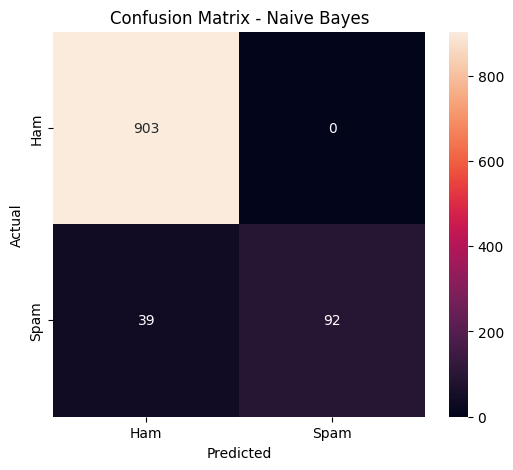

In [49]:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["ham", "spam"])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5700)
Testing TF-IDF shape: (1034, 5700)


In [51]:
nb_model_improved = MultinomialNB()

nb_model_improved.fit(X_train_tfidf, y_train)

y_pred_nb_improved = nb_model_improved.predict(X_test_tfidf)

print("Improved Naive Bayes trained successfully!")

Improved Naive Bayes trained successfully!


In [52]:
accuracy_nb_improved = accuracy_score(y_test, y_pred_nb_improved)
precision_nb_improved = precision_score(
    y_test, y_pred_nb_improved, pos_label="spam"
)
recall_nb_improved = recall_score(
    y_test, y_pred_nb_improved, pos_label="spam"
)
f1_nb_improved = f1_score(
    y_test, y_pred_nb_improved, pos_label="spam"
)

print(f"Accuracy : {accuracy_nb_improved:.4f}")
print(f"Precision: {precision_nb_improved:.4f}")
print(f"Recall   : {recall_nb_improved:.4f}")
print(f"F1 Score : {f1_nb_improved:.4f}")

Accuracy : 0.9662
Precision: 1.0000
Recall   : 0.7328
F1 Score : 0.8458


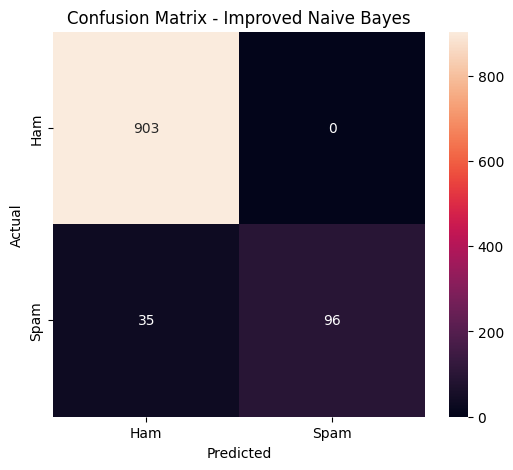

In [53]:
cm_improved = confusion_matrix(
    y_test,
    y_pred_nb_improved,
    labels=["ham", "spam"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Improved Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [54]:
def predict_spam(message):
    cleaned_message = preprocess_text(message)
    message_tfidf = tfidf.transform([cleaned_message])
    prediction = nb_model_improved.predict(message_tfidf)[0]

    return prediction


test_messages = [
    "Congratulations! You have won a free prize. Call now to claim it!",
    "Hey, are you coming to college tomorrow?",
    "URGENT! You have been selected for a cash reward. Claim now!",
    "Can you send me the notes after class?"
]

for message in test_messages:
    prediction = predict_spam(message)
    print("Message:", message)
    print("Prediction:", prediction.upper())
    print("-" * 80)

Message: Congratulations! You have won a free prize. Call now to claim it!
Prediction: SPAM
--------------------------------------------------------------------------------
Message: Hey, are you coming to college tomorrow?
Prediction: HAM
--------------------------------------------------------------------------------
Message: URGENT! You have been selected for a cash reward. Claim now!
Prediction: SPAM
--------------------------------------------------------------------------------
Message: Can you send me the notes after class?
Prediction: HAM
--------------------------------------------------------------------------------
